In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [175]:
import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras import callbacks
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall

In [176]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from PIL import Image
import matplotlib.image as img

In [182]:
train_dir = "/kaggle/input/brain-stroke-ct-scan-image/Brain_Stroke_CT-SCAN_image/Train"
val_dir="/kaggle/input/brain-stroke-ct-scan-image/Brain_Stroke_CT-SCAN_image/Validation"
test_dir = "/kaggle/input/brain-stroke-ct-scan-image/Brain_Stroke_CT-SCAN_image/Validation"

resize_size = (240,240)

batch_size = 32

In [183]:
#train_data 
train_data = tf.keras.preprocessing.image_dataset_from_directory(
    directory = train_dir ,
    image_size = resize_size ,
    label_mode = "categorical" ,
    batch_size = batch_size 
    )

#Classes Names
class_names= train_data.class_names
class_names

#labels are one-hot encoded

Found 1850 files belonging to 2 classes.


['Normal', 'Stroke']

In [184]:
val_data = tf.keras.preprocessing.image_dataset_from_directory(
    directory = val_dir ,
    image_size = resize_size ,
    label_mode = "categorical" ,
    batch_size = batch_size ,
    )


Found 347 files belonging to 2 classes.


In [185]:
test_data = tf.keras.preprocessing.image_dataset_from_directory(
    directory = test_dir ,
    image_size = resize_size ,
    label_mode = "categorical" ,
    batch_size = batch_size ,
    )

Found 347 files belonging to 2 classes.


# Visualise images¶

In [186]:
def showSampleImages(data):
    class_names=data.class_names
    plt.figure(figsize=(12, 12))
    for images,labels in data.take(1):
        for i in range(9):
            ax = plt.subplot(3, 3, i + 1)
            plt.imshow(images[i].numpy().astype("uint8"))
            plt.title(class_names[tf.argmax(labels[i])])
            plt.axis("off")

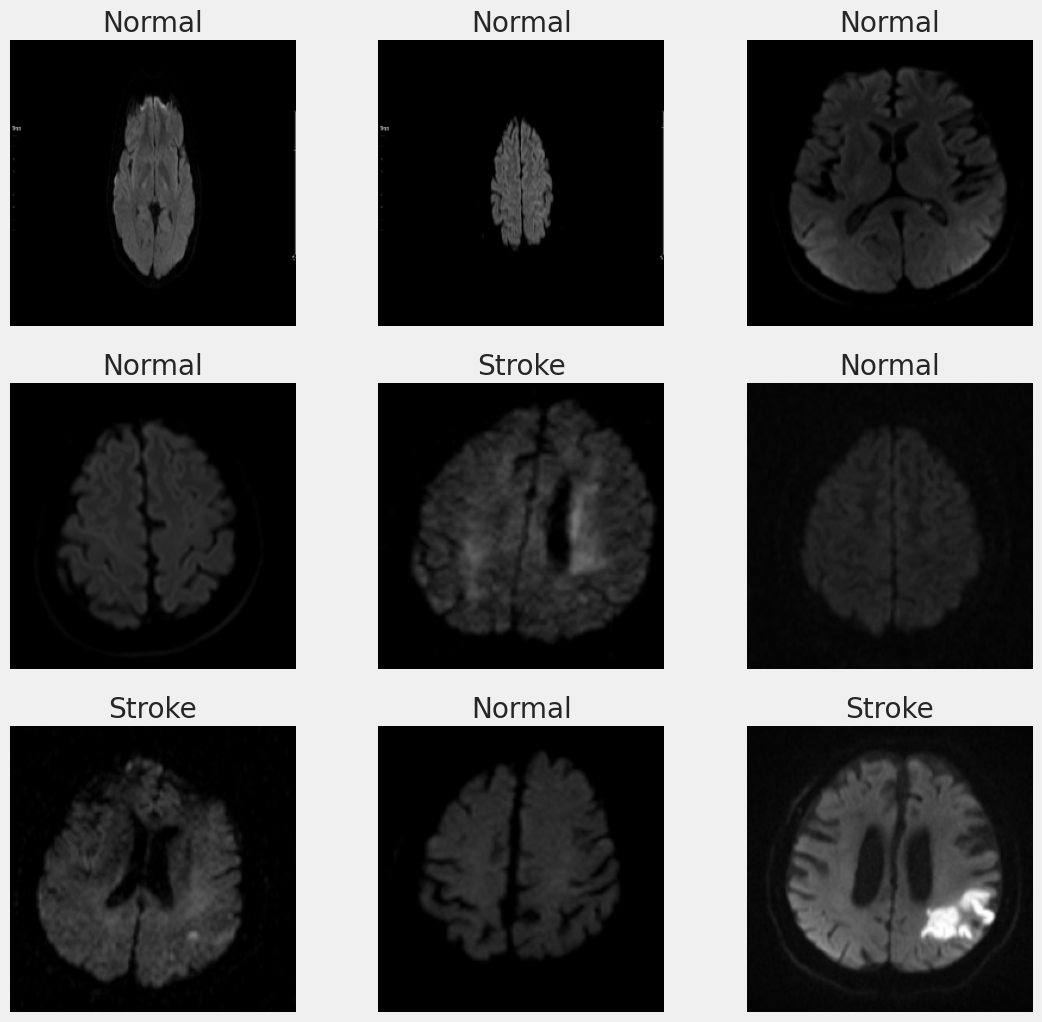

In [187]:
showSampleImages(train_data)

# Ckecking Count of data

In [ ]:
def print_count_and_bar_graph(data,data_name,pallete_style="deep"):
    class_names=data.class_names
    ds=pd.DataFrame({'Class':class_names,'Count':len(class_names)*[0]})
    
    #Looping over the data
    for images,labels in data:
        for i in range(len(images)):
            for category in class_names:
                if class_names[tf.argmax(labels[i])]==category:
                    ds.loc[ds['Class']==category,'Count']+=1
    #print count
    for category in class_names:
        print(f"{category} : {ds.loc[ds['Class']==category,'Count']}")

    #print bar plot
    plt.figure(figsize=(12,7))
    ax = sns.barplot(data=ds , x='Class',y='Count', palette=pallete_style)
    sns.set(style="dark",palette="colorblind")
    plt.title('Count of images in each class of '+data_name, fontsize=20)
    ax.bar_label(ax.containers[0])
    plt.show()


Normal : 0    889
Name: Count, dtype: int64
Stroke : 1    961
Name: Count, dtype: int64


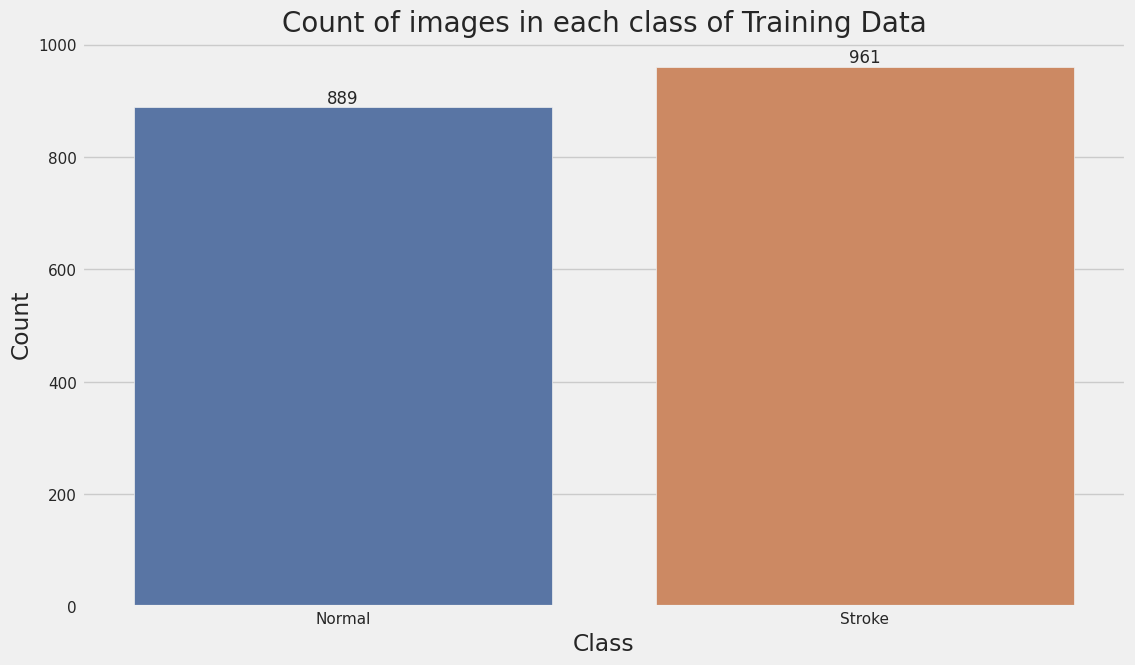

In [188]:
print_count_and_bar_graph(train_data,"Training Data")

Normal : 0    889
Name: Count, dtype: int64
Stroke : 1    961
Name: Count, dtype: int64


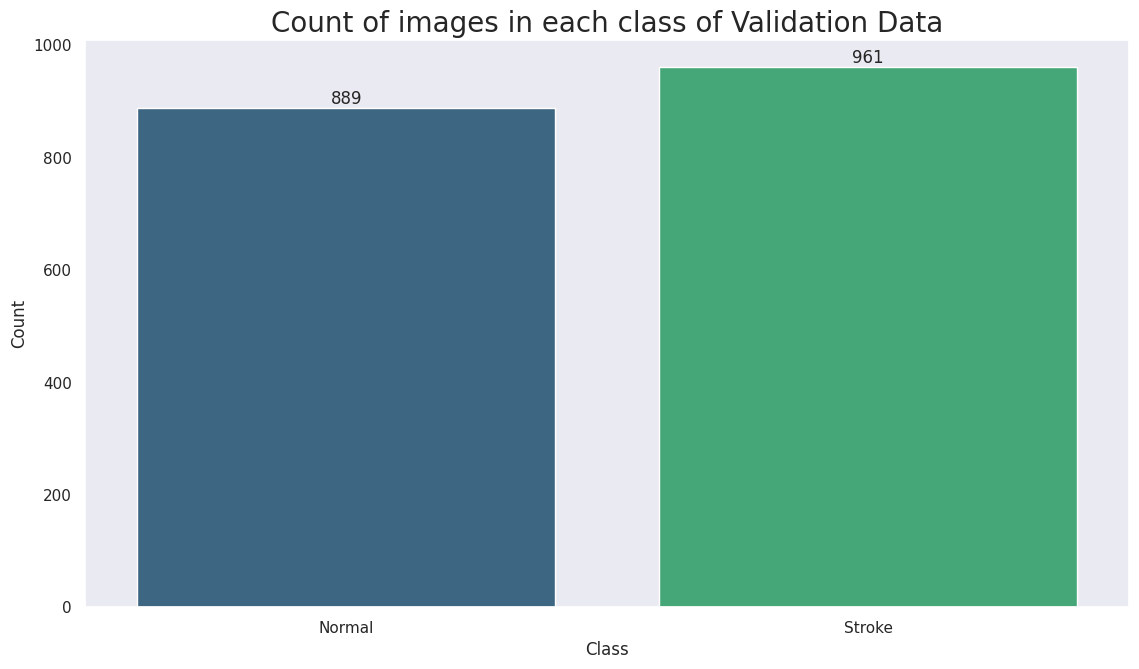

In [189]:
print_count_and_bar_graph(train_data,"Validation Data",pallete_style="viridis")

Normal : 0    167
Name: Count, dtype: int64
Stroke : 1    180
Name: Count, dtype: int64


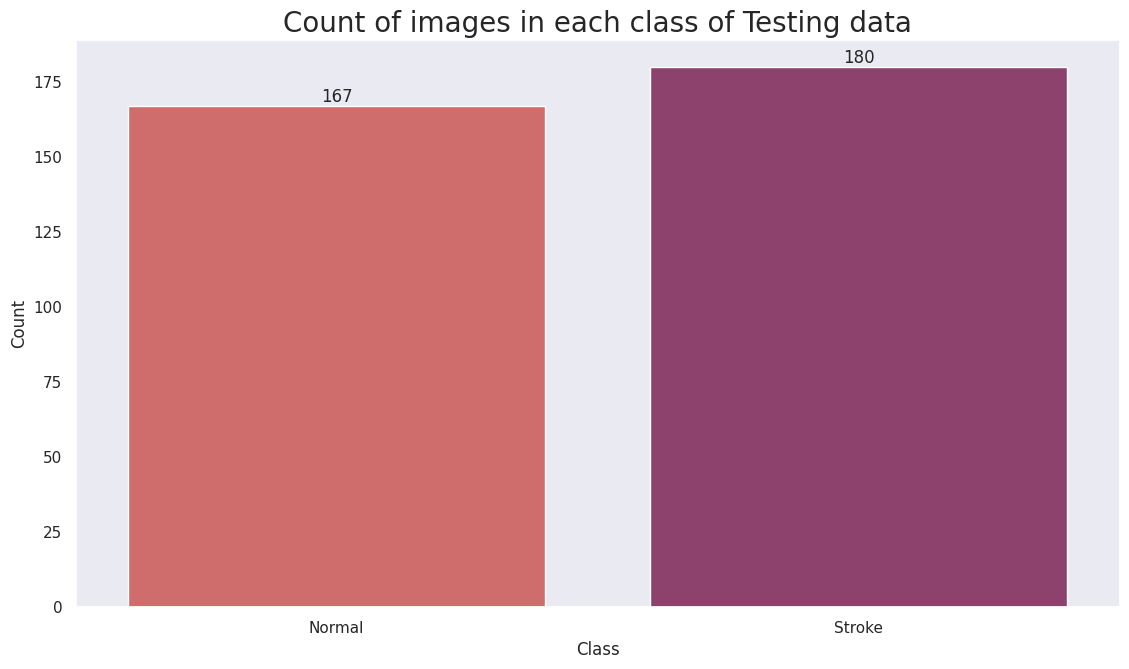

In [190]:
print_count_and_bar_graph(test_data,"Testing data",pallete_style="flare")

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.applications import vgg16
from tensorflow.keras.optimizers import Adam, SGD

In [191]:
img_size=(240,240,3)

vgg = vgg16.VGG16(weights='imagenet', include_top=False, input_shape = img_size)

  

In [192]:
vgg.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 240, 240, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 240, 240, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 240, 240, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 120, 120, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 120, 120, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 120, 120, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 60, 60, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 60, 60, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 60, 60, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 60, 60, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 30, 30, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 30, 30, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 30, 30, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 30, 30, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 15, 15, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 15, 15, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 15, 15, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 15, 15, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [193]:

for layer in vgg.layers[:-5]:    #Set block5 trainable, all others as non-trainable
    print(layer.name)
    layer.trainable = False #All others as non-trainable.

input_layer_1
block1_conv1
block1_conv2
block1_pool
block2_conv1
block2_conv2
block2_pool
block3_conv1
block3_conv2
block3_conv3
block3_pool
block4_conv1
block4_conv2
block4_conv3


In [194]:
def get_model(input_shape = img_size):
    x = vgg.output
    x = GlobalAveragePooling2D()(x) #Using GlobalAveragePooling in place of flatten. 
    x = Dense(2, activation="softmax")(x)  #defining this as multiclass problem. 

    model = Model(vgg.input, x)
    model.compile(loss = "categorical_crossentropy", 
                  optimizer = SGD(learning_rate=0.0001, momentum=0.9),
                  metrics=['accuracy', Precision(), Recall()])
    
    return model

In [195]:
callback_list=[
    callbacks.EarlyStopping(monitor="val_accuracy",patience=10,restore_best_weights=True),
    callbacks.ReduceLROnPlateau(factor=0.8,monitor="val_accuracy",patience=3)
]

In [196]:
model=get_model(input_shape=img_size)

In [197]:
model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 240, 240, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 240, 240, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 240, 240, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 120, 120, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 120, 120, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 120, 120, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 60, 60, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 60, 60, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 60, 60, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 60, 60, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 30, 30, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 30, 30, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 30, 30, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 30, 30, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 15, 15, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 15, 15, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 15, 15, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 15, 15, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,715,714 (56.14 MB)

 Trainable params: 7,080,450 (27.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [ ]:
tf.keras.utils.plot_model(model, show_shapes=True)

In [199]:
Model_History = model.fit(train_data 
                              ,validation_data = val_data ,
                              epochs = 25  ,
                              verbose = 1 ,
                              callbacks = callback_list)

Epoch 1/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 16s 219ms/step - accuracy: 0.5500 - loss: 0.7110 - precision_1: 0.5500 - recall_1: 0.5500 - val_accuracy: 0.4805 - val_loss: 0.7040 - val_precision_1: 0.4805 - val_recall_1: 0.4805 - learning_rate: 1.0000e-04
Epoch 2/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 187ms/step - accuracy: 0.7016 - loss: 0.6220 - precision_1: 0.7016 - recall_1: 0.7016 - val_accuracy: 0.4805 - val_loss: 0.7695 - val_precision_1: 0.4805 - val_recall_1: 0.4805 - learning_rate: 1.0000e-04
Epoch 3/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 186ms/step - accuracy: 0.7079 - loss: 0.5807 - precision_1: 0.7079 - recall_1: 0.7079 - val_accuracy: 0.4805 - val_loss: 0.8219 - val_precision_1: 0.4805 - val_recall_1: 0.4805 - learning_rate: 1.0000e-04
Epoch 4/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 12s 190ms/step - accuracy: 0.7174 - loss: 0.5585 - precision_1: 0.7174 - recall_1: 0.7174 - val_accuracy: 0.4805 - val_loss: 0.8576 - val_precision_1: 0.4805 - val_recall_1: 0.4805 - learning_rate: 1.0000e-04
Epoch 5/25
5

# Evaluate Model

In [ ]:
def plot_metrices_graphs(Model_History, start=0):
    metrices = {
        "train_Loss": Model_History.history['loss'],
        "val_Loss": Model_History.history['val_loss'],
        "train_Accuracy": Model_History.history['accuracy'],
        "val_Accuracy": Model_History.history['val_accuracy'],
        "train_Precision": Model_History.history['precision'],
        "val_Precision": Model_History.history['val_precision'],
        "train_Recall": Model_History.history['recall'],
        "val_Recall": Model_History.history['val_recall']
    }

    bestEpoch = {
        "Loss": np.argmin(metrices["val_Loss"]),
        "Accuracy": np.argmax(metrices["val_Accuracy"]),
        "Precision": np.argmax(metrices["val_Precision"]),
        "Recall": np.argmax(metrices["val_Recall"])
    }

    Epochs = [i + 1 for i in range(start, len(metrices['train_Accuracy']))]

    plt.figure(figsize=(20, 12))
    plt.style.use('fivethirtyeight')

    i = 0
    for j in range(0, 4):
        plt.subplot(2, 2, j+1)
        plt.plot(Epochs, metrices["train_" + list(bestEpoch.keys())[j]], 'r', label=f'Training {list(bestEpoch.keys())[j]}')
        plt.plot(Epochs, metrices["val_" + list(bestEpoch.keys())[j]], 'g', label=f'Validation {list(bestEpoch.keys())[j]}')
        plt.scatter(bestEpoch[list(bestEpoch.keys())[j]], metrices["val_" + list(bestEpoch.keys())[j]][bestEpoch[list(bestEpoch.keys())[j]]], s=150, c='blue', label=f'Best Epoch = {bestEpoch[list(bestEpoch.keys())[j]]}')
        plt.title(f'Training and Validation {list(bestEpoch.keys())[j]}')
        plt.xlabel('Epochs')
        plt.ylabel(f'{list(bestEpoch.keys())[j]}')
        plt.legend()
        plt.grid(True)
        i += 1

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.5, wspace=0.5)
    plt.show()


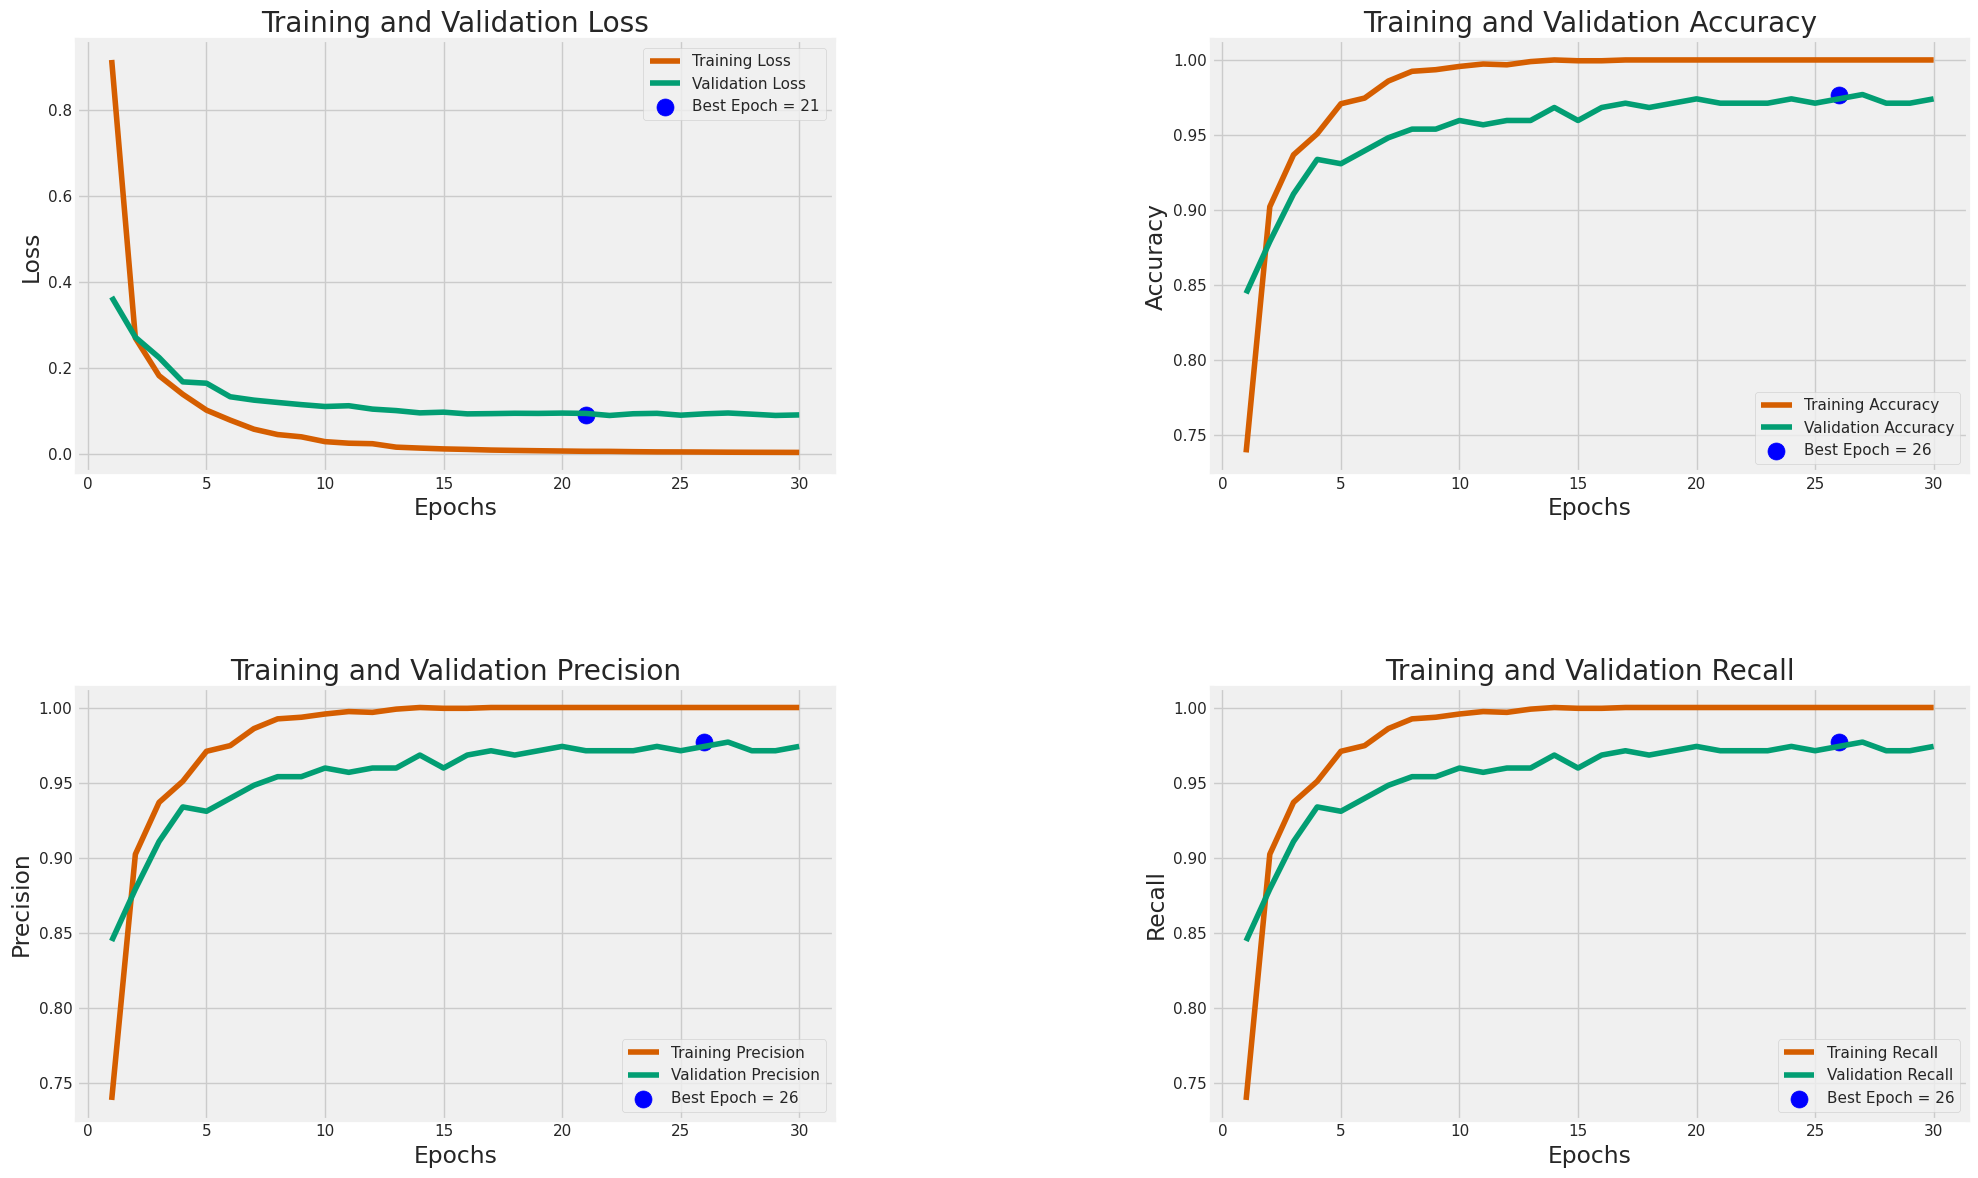

In [174]:
plot_metrices_graphs(Model_History)

In [ ]:
def Evaluate_Model(model,train_data,test_data):
    train_score = model.evaluate(train_data, verbose=1)
    test_score = model.evaluate(test_data,verbose=1)

    print(f"Train Loss: {train_score[0]:.4f}")
    print(f"Train Accuracy: {train_score[1]*100:.2f}%")
    print('-' * 30)
    print(f"Test Loss: {test_score[0]:.4f}")
    print(f"Test Accuracy: {test_score[1]*100:.2f}%")

In [167]:
Evaluate_Model(model,train_data,test_data)

58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - accuracy: 1.0000 - loss: 0.0047 - precision: 1.0000 - recall: 1.0000
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.9807 - loss: 0.0913 - precision: 0.9807 - recall: 0.9807
Train Loss: 0.0046
Train Accuracy: 100.00%
------------------------------
Test Loss: 0.0936
Test Accuracy: 97.69%


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

In [165]:
def printClassificationReportAndConfusionMaxtrix(model, class_names, data):
    true_labels = []
    predicted_labels = []

    for images, labels in data:
        true_labels.extend(np.argmax(labels.numpy(),axis=1))  # Convert one-hot encoded labels to class indices
        predicted_labels.extend(np.argmax(model.predict(images),axis=1))  # Obtain model predictions

    # Print classification report
    print("\n" * 5)
    print(classification_report(true_labels, predicted_labels, target_names=class_names))
    print("\n" * 5)

    # Compute the confusion matrix
    conf_matrix = confusion_matrix(true_labels, predicted_labels)

    # Plot the confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step






              precision    recall  f1-score   support

      Normal       0.96      0.99      0.98       167
      Stroke       0.99      0.97      0.98       180

    accuracy                           0.98       347
   macro avg       0.98      0.98      0.98       347
weighted avg       0.98      0.98      0.98       347









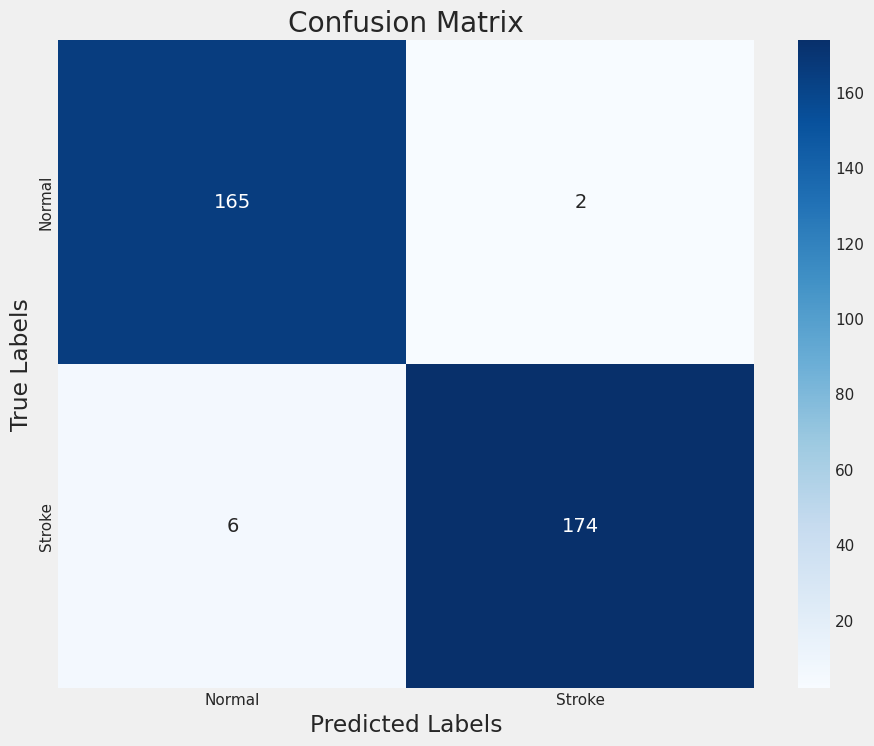

In [166]:
printClassificationReportAndConfusionMaxtrix(model,class_names,test_data)

# Segmentation

In [ ]:
from matplotlib.patches import Rectangle #To add a rectangle overlay to the image
from skimage.feature.peak import peak_local_max  #To detect hotspots in 2D images. 

In [ ]:
def plot_heatmap(img):
  
    pred = model.predict(np.expand_dims(img, axis=0))
    pred_class = np.argmax(pred)
    #Get weights for all classes from the prediction layer
    last_layer_weights = model.layers[-1].get_weights()[0] #Prediction layer
    #Get weights for the predicted class.
    last_layer_weights_for_pred = last_layer_weights[:, pred_class]
    #Get output from the last conv. layer
    last_conv_model = Model(model.input, model.get_layer("block5_conv3").output)
    last_conv_output = last_conv_model.predict(img[np.newaxis,:,:,:])
    last_conv_output = np.squeeze(last_conv_output)
    
    #Upsample/resize the last conv. output to same size as original image
    h = int(img.shape[0]/last_conv_output.shape[0])
    w = int(img.shape[1]/last_conv_output.shape[1])
    upsampled_last_conv_output = scipy.ndimage.zoom(last_conv_output, (h, w, 1), order=1)
    
    heat_map = np.dot(upsampled_last_conv_output.reshape((img.shape[0]*img.shape[1], 512)), 
                 last_layer_weights_for_pred).reshape(img.shape[0],img.shape[1])
    
    #Since we have a lot of dark pixels where the edges may be thought of as 
    #high anomaly, let us drop all heat map values in this region to 0.
    #This is an optional step based on the image. 
    heat_map[img[:,:,0] == 0] = 0  #All dark pixels outside the object set to 0
    
    #Detect peaks (hot spots) in the heat map. We will set it to detect maximum 5 peaks.
    #with rel threshold of 0.5 (compared to the max peak). 
    peak_coords = peak_local_max(heat_map, num_peaks=5, threshold_rel=0.5, min_distance=10) 

    plt.imshow(img.astype('float32').reshape(img.shape[0],img.shape[1],3))
    plt.imshow(heat_map, cmap='jet', alpha=0.30)
    for i in range(0,peak_coords.shape[0]):
        print(i)
        y = peak_coords[i,0]
        x = peak_coords[i,1]
        plt.gca().add_patch(Rectangle((x-25, y-25), 50,50,linewidth=1,edgecolor='r',facecolor='none'))
